# Bank Nifty 09:20 Short Strangle Backtest

Interactive notebook for the Qode Quant Research Analyst assignment.

**Strategy:** Sell 1 CE + 1 PE at 09:20 each day (strikes closest to Rs. 50 premium), exit at 15:20 or 50% stop-loss per leg.

**Outputs:** `backtest_output.xlsx`, `equity_curve.png`, `drawdown.png`

Core logic lives in [`short_strangle_backtest.py`](short_strangle_backtest.py).



## 1. Setup

In [6]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

import short_strangle_backtest as bt

BASE_DIR = Path(".").resolve()
bt.TIMINGS.clear()

print(f"Options file : {bt.OPTIONS_FILE.exists()} — {bt.OPTIONS_FILE.name}")
print(f"Spot file    : {bt.SPOT_FILE.exists()} — {bt.SPOT_FILE.name}")
print(f"Entry / Exit : {bt.ENTRY_TIME} → {bt.EXIT_TIME}")
print(f"Lot size     : {bt.QUANTITY} qty ({bt.LOTS} lot × {bt.LOT_SIZE})")

# Load data here so later cells work even if run out of order
print("\nLoading data...")
options = bt.load_options()
spot = bt.load_spot()
print(f"Options rows : {len(options):,} | Trading days : {options['Date'].nunique()}")
print(f"Spot rows    : {len(spot):,}")

Options file : True — Options_data_2023.csv
Spot file    : True — BANKNIFTY_SPOT.csv
Entry / Exit : 09:20:59 → 15:20:59
Lot size     : 15 qty (1 lot × 15)

Loading data...
Options rows : 9,845,373 | Trading days : 247
Spot rows    : 136,324


## 2. Load Data

Load 1-minute options bars (09:20–15:20 window) and Bank Nifty spot index.

In [7]:
# Data already loaded in Setup cell — re-run Setup first if you see NameError
print(f"Options rows : {len(options):,}")
print(f"Trading days : {options['Date'].nunique()}")
print(f"Time range   : {options['Time'].min()} → {options['Time'].max()}")
print(f"Spot rows    : {len(spot):,}")
options.head()

Options rows : 9,845,373
Trading days : 247
Time range   : 09:20:59 → 15:20:59
Spot rows    : 136,324


,Date,Ticker,Time,Open,High,Low,Close,Call/Put,strike,option_type,minute
522,2023-01-02,BANKNIFTY40500PE,09:20:59,8.45,9.05,8.40,8.75,PE,40500,PE,09:20
523,2023-01-02,BANKNIFTY40800PE,09:20:59,10.25,10.95,10.20,10.80,PE,40800,PE,09:20
524,2023-01-02,BANKNIFTY40900PE,09:20:59,11.10,11.90,10.95,11.65,PE,40900,PE,09:20
525,2023-01-02,BANKNIFTY41000CE,09:20:59,2076.70,2090.00,2051.00,2090.00,CE,41000,CE,09:20
526,2023-01-02,BANKNIFTY41100PE,09:20:59,13.10,14.20,12.95,13.90,PE,41100,PE,09:20


## 3. Strike Selection (09:20)

Pick CE and PE with 09:20 close **closest to Rs. 50** (tie-break: higher CE strike, lower PE strike).

In [8]:
entry_bars = options[options["Time"] == bt.ENTRY_TIME]
selected = bt.select_strikes(entry_bars)

print(f"Selected legs: {len(selected)} ({selected['Date'].nunique()} days × 2)")
sample_date = selected["Date"].iloc[0]
selected[selected["Date"] == sample_date]

Selected legs: 494 (247 days × 2)


,Date,Ticker,strike,option_type,entry_price,entry_time,minute
0,2023-01-02,BANKNIFTY44000CE,44000,CE,50.05,09:20:59,09:20
247,2023-01-02,BANKNIFTY42000PE,42000,PE,46.80,09:20:59,09:20


## 4. Signal Generation & Stop Loss

- **Entry:** 09:20 close (short)
- **Exit:** 15:20 close, or SL at `entry × 1.5` when `High` breaches stop (first hit minute)

In [9]:
trades_raw = bt.apply_signals(selected, options)

print("Exit reason breakdown:")
print(trades_raw["exit_reason"].value_counts())
trades_raw[trades_raw["Date"] == sample_date][[
    "Date", "Ticker", "option_type", "entry_price", "exit_time", "exit_price", "exit_reason"
]]

Exit reason breakdown:
exit_reason
Scheduled Exit    250
Stop Loss         244
Name: count, dtype: int64


,Date,Ticker,option_type,entry_price,exit_time,exit_price,exit_reason
0,2023-01-02,BANKNIFTY44000CE,CE,50.05,09:44:59,75.075,Stop Loss
247,2023-01-02,BANKNIFTY42000PE,PE,46.80,15:20:59,19.350,Scheduled Exit


## 5. Trade Sheet

Build full trade log with P&L, cumulative P&L, and available capital.

In [10]:
tradesheet = bt.build_tradesheet(trades_raw, spot)

print(f"Total trades : {len(tradesheet)}")
print(f"Trades/day   : {tradesheet.groupby('Entry Date').size().value_counts().to_dict()}")
print(f"Total P&L    : Rs. {tradesheet['Gross P&L'].sum():,.2f}")
tradesheet.head(6)

Total trades : 494
Trades/day   : {2: 247}
Total P&L    : Rs. 8,259.34


,Entry Date,Entry Time,Exit Date,Exit Time,Option Ticker,Strike Price,Option Type,Entry Price,Exit Price,Quantity,Entry Value,Exit Value,Gross P&L,Cumulative P&L,Available Capital,Banknifty Underlying Close,Exit Reason,Is Expiry Day,% P&L
0,2023-01-02,09:20:59,2023-01-02,15:20:59,BANKNIFTY42000PE,42000,PE,46.80,19.35,15,702.00,290.25,411.75,411.75,100036.38,NaN,Scheduled Exit,False,58.65
1,2023-01-02,09:20:59,2023-01-02,09:44:59,BANKNIFTY44000CE,44000,CE,50.05,75.07,15,750.75,1126.12,-375.37,36.38,100036.38,NaN,Stop Loss,False,-50.00
2,2023-01-03,09:20:59,2023-01-03,15:20:59,BANKNIFTY42500PE,42500,PE,46.50,20.45,15,697.50,306.75,390.75,427.13,100448.88,NaN,Scheduled Exit,False,56.02
3,2023-01-03,09:20:59,2023-01-03,15:20:59,BANKNIFTY44000CE,44000,CE,45.15,43.70,15,677.25,655.50,21.75,448.88,100448.88,NaN,Scheduled Exit,False,3.21
4,2023-01-04,09:20:59,2023-01-04,09:43:59,BANKNIFTY43000PE,43000,PE,54.85,82.28,15,822.75,1234.12,-411.38,37.50,100491.25,NaN,Stop Loss,True,-50.00
5,2023-01-04,09:20:59,2023-01-04,15:20:59,BANKNIFTY44000CE,44000,CE,40.95,10.70,15,614.25,160.50,453.75,491.25,100491.25,NaN,Scheduled Exit,True,73.87


## 6. Statistical Analysis

In [11]:
stats = bt.compute_statistics(tradesheet)

display(stats["summary"])
display(stats["win_loss"])
display(stats["expiry_stats"])
display(stats["monthly_table"])

,Metric,Value
0,Starting Capital (INR),100000
1,Base NAV,100.0
2,Final NAV,108.2593
3,Total Gross P&L (INR),8259.34
4,CAGR,8.27%
5,Max Drawdown,-3.11%
6,Total Trading Days,247
7,Total Trades,494
8,SL Exits,244
9,Scheduled Exits,250


,Category,Winners,Losers,Win %,Loss %,Avg % P&L
0,CE,123,124,49.80,50.20,2.13
1,PE,122,125,49.39,50.61,0.94
2,Combined,245,249,49.60,50.40,1.53


,Segment,Day Type,Trades,Avg % P&L,Avg Gross P&L
0,CE,Expiry Days (Wed),52,11.23,87.08
1,CE,Non-Expiry Days,195,-0.30,6.68
2,PE,Expiry Days (Wed),52,-0.89,2.01
3,PE,Non-Expiry Days,195,1.43,11.92
4,Combined,Expiry Days (Wed),104,5.17,44.55
5,Combined,Non-Expiry Days,390,0.57,9.30


,Month,End NAV,Monthly % P&L
0,2023-01,98.9331,-1.0669
1,2023-02,97.7312,-1.2149
2,2023-03,100.0255,2.3475
3,2023-04,101.1134,1.0876
4,2023-05,104.1827,3.0356
5,2023-06,105.9666,1.7123
6,2023-07,106.4335,0.4406
7,2023-08,105.0186,-1.3293
8,2023-09,104.9999,-0.0179
9,2023-10,106.3514,1.2872


## 7. Equity Curve & Drawdown

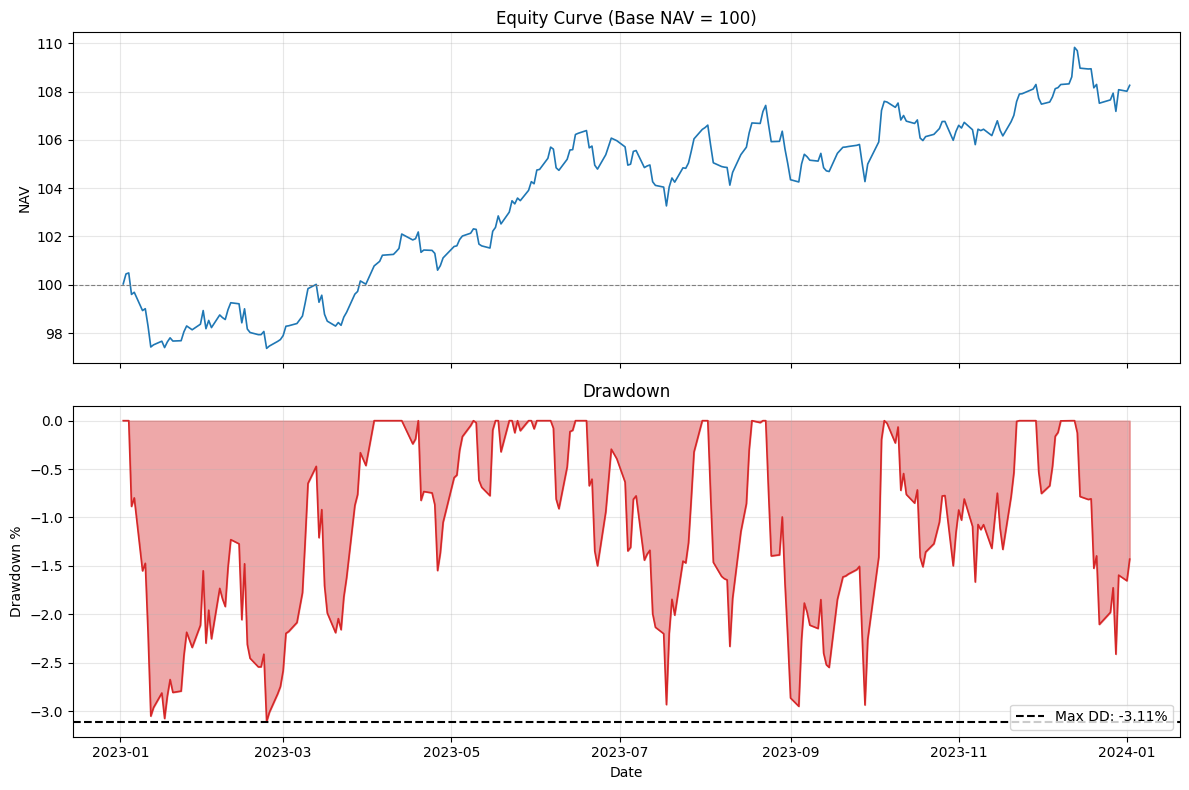

In [12]:
nav = stats["nav"]
drawdown = stats["drawdown"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(nav.index, nav.values, color="#1f77b4", linewidth=1.2)
axes[0].axhline(bt.BASE_NAV, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Equity Curve (Base NAV = 100)")
axes[0].set_ylabel("NAV")
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(drawdown.index, drawdown.values, 0, color="#d62728", alpha=0.4)
axes[1].plot(drawdown.index, drawdown.values, color="#d62728", linewidth=1.2)
axes[1].axhline(stats["max_dd"], color="black", linestyle="--",
                label=f"Max DD: {stats['max_dd']:.2f}%")
axes[1].set_title("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Drawdown %")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Export Results

Save Excel workbook and PNG charts (same files produced by `python short_strangle_backtest.py`).

In [13]:
total_t0 = time.perf_counter()
bt.save_plots(stats["nav"], stats["drawdown"], stats["max_dd"])
bt.export_excel(tradesheet, stats, total_t0)

print("=== Exported ===")
for path in [bt.OUTPUT_XLSX, bt.EQUITY_PNG, bt.DRAWDOWN_PNG]:
    print(f"  {path.name} ({path.stat().st_size:,} bytes)")

print("\nRuntime (seconds):")
for k, v in bt.TIMINGS.items():
    print(f"  {k}: {v:.3f}")

=== Exported ===
  backtest_output.xlsx (56,075 bytes)
  equity_curve.png (81,800 bytes)
  drawdown.png (128,756 bytes)

Runtime (seconds):
  1_load_options_sec: 30.247
  2_load_spot_sec: 0.897
  3_strike_selection_sec: 0.035
  4_signal_stoploss_sec: 4.547
  5_tradesheet_sec: 0.055
  6_statistics_sec: 0.017
  7_plots_sec: 0.323
  8_excel_export_prep_sec: 0.001
  total_sec: 0.323
  8_excel_write_sec: 0.439


## 9. Quick Validation (sample day)

Manual check: strike selection and P&L signs for the first trading day.

In [14]:
day = tradesheet[tradesheet["Entry Date"] == sample_date]
display(day[[
    "Option Type", "Option Ticker", "Entry Price", "Exit Price",
    "Gross P&L", "Exit Time", "Banknifty Underlying Close"
]])

for _, row in day.iterrows():
    expected = (row["Entry Price"] - row["Exit Price"]) * row["Quantity"]
    print(f"{row['Option Type']}: expected P&L = {expected:.2f}, actual = {row['Gross P&L']:.2f}")

,Option Type,Option Ticker,Entry Price,Exit Price,Gross P&L,Exit Time,Banknifty Underlying Close
0,PE,BANKNIFTY42000PE,46.80,19.35,411.75,15:20:59,NaN
1,CE,BANKNIFTY44000CE,50.05,75.07,-375.37,09:44:59,NaN


PE: expected P&L = 411.75, actual = 411.75
CE: expected P&L = -375.30, actual = -375.37
